# Import libraries

In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report,confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB

# Import Data

In [5]:
cols=['Length','Width','Size','Conc','Conc1','Asym','M3Long','M3Trans','Alpha','Dist','Class']
df=pd.read_csv('magic04.data',names=cols)

In [6]:
print(df.head(5))

     Length     Width    Size    Conc   Conc1      Asym   M3Long  M3Trans  \
0   28.7967   16.0021  2.6449  0.3918  0.1982   27.7004  22.0110  -8.2027   
1   31.6036   11.7235  2.5185  0.5303  0.3773   26.2722  23.8238  -9.9574   
2  162.0520  136.0310  4.0612  0.0374  0.0187  116.7410 -64.8580 -45.2160   
3   23.8172    9.5728  2.3385  0.6147  0.3922   27.2107  -6.4633  -7.1513   
4   75.1362   30.9205  3.1611  0.3168  0.1832   -5.5277  28.5525  21.8393   

     Alpha      Dist Class  
0  40.0920   81.8828     g  
1   6.3609  205.2610     g  
2  76.9600  256.7880     g  
3  10.4490  116.7370     g  
4   4.6480  356.4620     g  


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19020 entries, 0 to 19019
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Length   19020 non-null  float64
 1   Width    19020 non-null  float64
 2   Size     19020 non-null  float64
 3   Conc     19020 non-null  float64
 4   Conc1    19020 non-null  float64
 5   Asym     19020 non-null  float64
 6   M3Long   19020 non-null  float64
 7   M3Trans  19020 non-null  float64
 8   Alpha    19020 non-null  float64
 9   Dist     19020 non-null  float64
 10  Class    19020 non-null  object 
dtypes: float64(10), object(1)
memory usage: 1.6+ MB
None


In [8]:
print(df.describe())

             Length         Width          Size          Conc         Conc1  \
count  19020.000000  19020.000000  19020.000000  19020.000000  19020.000000   
mean      53.250154     22.180966      2.825017      0.380327      0.214657   
std       42.364855     18.346056      0.472599      0.182813      0.110511   
min        4.283500      0.000000      1.941300      0.013100      0.000300   
25%       24.336000     11.863800      2.477100      0.235800      0.128475   
50%       37.147700     17.139900      2.739600      0.354150      0.196500   
75%       70.122175     24.739475      3.101600      0.503700      0.285225   
max      334.177000    256.382000      5.323300      0.893000      0.675200   

               Asym        M3Long       M3Trans         Alpha          Dist  
count  19020.000000  19020.000000  19020.000000  19020.000000  19020.000000  
mean      -4.331745     10.545545      0.249726     27.645707    193.818026  
std       59.206062     51.000118     20.827439     26

# Check for data imbalance

In [10]:
print(df.groupby("Class")["Class"].count())
# Slightly imbalanced

Class
g    12332
h     6688
Name: Class, dtype: int64


In [11]:
df["Class"]=(df["Class"]=="h").astype(int)

X=df.drop("Class",axis=1)
y=df["Class"]

In [12]:
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.8,random_state=44)

# Hyper paramater tuning/Roc curve

In [157]:
models = {
    "SVC": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("SVC", SVC(kernel="linear", class_weight="balanced"))
        ]),
        "params": {
            "SVC__C": [0.01, 0.1, 1, 5]
        }
    },

    "XGBoost": {
        "pipeline": XGBClassifier(
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1,
            scale_pos_weight=12332 / 6688  # ≈ 1.84
        ),
        "params": {
            "n_estimators": [100, 150, 200],
            "max_depth": [3, 4, 5],
            "learning_rate": [0.05, 0.1, 0.2],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0]
        }
    },

    "LightGBM": {
        "pipeline": LGBMClassifier(
            is_unbalance=True,
            random_state=42,
            n_jobs=-1
        ),
        "params": {
            "n_estimators": [100, 150, 200],
            "max_depth": [-1, 3, 5],
            "learning_rate": [0.05, 0.1, 0.2],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0]
        }
    },

    "GaussianNB": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("GaussianNB", GaussianNB())
        ]),
        "params": {
            # For GaussianNB, you can tune 'var_smoothing' (numerical stability)
            "GaussianNB__var_smoothing": [1e-9, 1e-8, 1e-7]
        }
    }
}

In [159]:
models_grid = {}

for name, config in models.items():

    search = RandomizedSearchCV(
        estimator=config["pipeline"],
        param_distributions=config["params"],
        n_iter=3,               #  number of random combinations to test
        scoring="roc_auc",
        cv=3,                   # fewer folds for faster run
        n_jobs=-1,              #  parallel execution on all CPU cores
        random_state=42,        #  reproducibility
        verbose=1
    )
    
    search.fit(X, y)
    print(f"Best params for {name}: {search.best_params_}")
    
    models_grid[name] = search


Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best params for SVC: {'SVC__C': 0.1}
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best params for XGBoost: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Fitting 3 folds for each of 3 candidates, totalling 9 fits
[LightGBM] [Info] Number of positive: 6688, number of negative: 12332
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001391 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 19020, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.351630 -> initscore=-0.611883
[LightGBM] [Info] Start training from score -0.611883
Best params for LightGBM: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': -1, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Fitting 3 folds for each of 3 cand

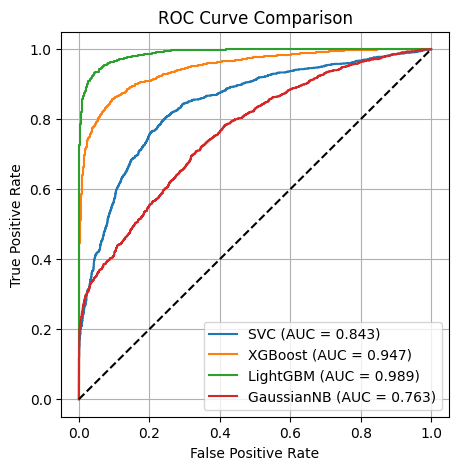

In [160]:
plt.figure(figsize=(5, 5))

for name, grid in models_grid.items():
    # Handle models with/without predict_proba
    if hasattr(grid, "predict_proba"):
        y_scores = grid.predict_proba(X_test)[:, 1]
    else:
        y_scores = grid.decision_function(X_test)

    # Compute ROC and AUC
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    auc_score = roc_auc_score(y_test, y_scores)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

# Add reference line
plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


In [169]:
chosen_model=models_grid["LightGBM"]
chosen_model.fit(X_train,y_train)
y_pred=chosen_model.predict(X_test)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
[LightGBM] [Info] Number of positive: 5303, number of negative: 9913
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001198 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 15216, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348515 -> initscore=-0.625574
[LightGBM] [Info] Start training from score -0.625574


In [170]:
cr=classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.90      0.91      0.91      2419
           1       0.84      0.83      0.84      1385

    accuracy                           0.88      3804
   macro avg       0.87      0.87      0.87      3804
weighted avg       0.88      0.88      0.88      3804



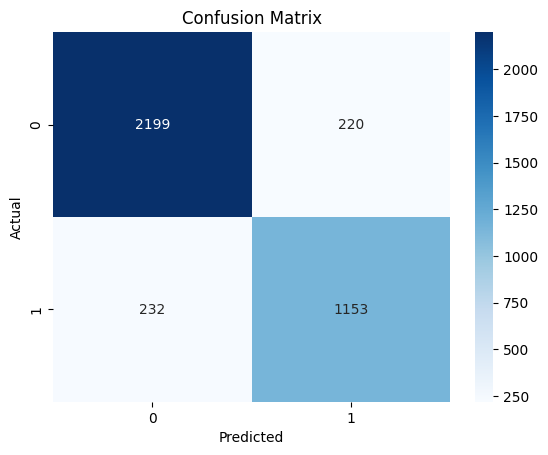

In [171]:
sns.heatmap(confusion_matrix(y_test,y_pred),cmap="Blues",fmt="d",annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()